<a href="https://colab.research.google.com/github/aansikkaw/Global-SEO-Market-Expansion-Analytics/blob/main/SEO_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('big-sports.csv')

# Display basic info and head
print("Data Info:")
print(df.info())
print("\nData Head:")
print(df.head())

# Check for duplicates
print(f"\nDuplicates: {df.duplicated().sum()}")

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Basic stats
print("\nDescriptive Stats:")
print(df.describe())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   keyword              100 non-null    object 
 1   country              100 non-null    object 
 2   avg_position         100 non-null    float64
 3   clicks               100 non-null    int64  
 4   impressions          100 non-null    int64  
 5   page                 100 non-null    object 
 6   competitor_position  100 non-null    float64
 7   search_volume        100 non-null    int64  
 8   ctr                  100 non-null    float64
dtypes: float64(3), int64(3), object(3)
memory usage: 7.2+ KB
None

Data Head:
             keyword country  avg_position  clicks  impressions  \
0         F1 results      IT          18.5    4093         4477   
1         UFC fights      FR          11.3     448        31325   
2       NBA playoffs      FR          27.0    4462      

In [2]:
# Check CTR calculation
df['calculated_ctr'] = df['clicks'] / df['impressions']
df['ctr_diff'] = df['ctr'] - df['calculated_ctr']

print("CTR Check:")
print(df[['clicks', 'impressions', 'ctr', 'calculated_ctr', 'ctr_diff']].head(10))
print(f"\nMax Abs Diff: {df['ctr_diff'].abs().max()}")

# Check URL Mismatches
# Extract country code from URL (assuming format https://bigsports.news/CC/...)
df['url_country'] = df['page'].apply(lambda x: x.split('/')[3] if len(x.split('/')) > 3 else 'Unknown')
# Extract slug from URL
df['url_slug'] = df['page'].apply(lambda x: x.split('/')[-1] if len(x.split('/')) > 0 else 'Unknown')

print("\nURL Mismatch Check (Country):")
print(df[df['country'] != df['url_country']][['country', 'url_country', 'page']].head())

print("\nURL Mismatch Check (Content - heuristic):")
# Just looking at head to see if keywords match slugs
print(df[['keyword', 'url_slug']].head(10))

CTR Check:
   clicks  impressions     ctr  calculated_ctr  ctr_diff
0    4093         4477  0.9142        0.914228 -0.000028
1     448        31325  0.0143        0.014302 -0.000002
2    4462        28777  0.1551        0.155054  0.000046
3    4158        30757  0.1352        0.135189  0.000011
4     832        30391  0.0274        0.027377  0.000023
5     136        14594  0.0093        0.009319 -0.000019
6    3881        27047  0.1435        0.143491  0.000009
7    1352        45167  0.0299        0.029933 -0.000033
8     636        42258  0.0151        0.015050  0.000050
9     970        12218  0.0794        0.079391  0.000009

Max Abs Diff: 4.999999999999449e-05

URL Mismatch Check (Country):
  country url_country                                            page
0      IT          EN     https://bigsports.news/EN/tennis-live-score
1      FR          IT      https://bigsports.news/IT/golf-leaderboard
2      FR          BR  https://bigsports.news/BR/cricket-live-updates
4      EN     

In [3]:
# 1. Data Quality Checks
invalid_ctr_mask = df['clicks'] > df['impressions']
invalid_ctr_rows = df[invalid_ctr_mask]
print(f"Rows with Clicks > Impressions: {len(invalid_ctr_rows)}")
print(invalid_ctr_rows[['keyword', 'clicks', 'impressions', 'ctr']])

# Country Mismatch
country_mismatch_count = df[df['country'] != df['url_country']].shape[0]
print(f"Country Mismatch Count: {country_mismatch_count}")

# 2. Performance Analysis
# Top Keywords by Clicks
top_keywords = df.groupby('keyword')['clicks'].sum().sort_values(ascending=False).head(5)
print("\nTop Keywords by Clicks:")
print(top_keywords)

# Market Analysis
market_stats = df.groupby('country').agg({
    'clicks': 'sum',
    'impressions': 'sum',
    'search_volume': 'sum',
    'keyword': 'count'
}).sort_values('search_volume', ascending=False)
market_stats['ctr'] = market_stats['clicks'] / market_stats['impressions']
print("\nMarket Stats:")
print(market_stats)

# 3. Opportunities
# High Potential (Volume > Median) but Poor Ranking (Pos > 5)
median_vol = df['search_volume'].median()
opportunities = df[
    (df['search_volume'] > median_vol) &
    (df['avg_position'] > 5)
].sort_values('search_volume', ascending=False)

print(f"\nOpportunities (Vol > {median_vol} & Pos > 5): {len(opportunities)}")
print(opportunities[['keyword', 'country', 'avg_position', 'search_volume', 'competitor_position']].head())

# Competitor Gap
competitor_gap = df[df['avg_position'] > df['competitor_position']].copy()
competitor_gap['gap'] = competitor_gap['avg_position'] - competitor_gap['competitor_position']
competitor_gap = competitor_gap.sort_values('gap', ascending=False)

print(f"\nCompetitor Gaps: {len(competitor_gap)}")
print(competitor_gap[['keyword', 'country', 'avg_position', 'competitor_position', 'gap']].head())

# 4. Correlation Analysis (Optional model part)
correlation = df[['avg_position', 'clicks', 'ctr']].corr()
print("\nCorrelation Matrix:")
print(correlation)

Rows with Clicks > Impressions: 6
            keyword  clicks  impressions      ctr
15     rugby scores    3579         1301   2.7510
29      MMA results    4979         4943   1.0073
54     betting tips    3824         3609   1.0596
63  betting bonuses    2911         2357   1.2350
76   NFL highlights    3443          213  16.1643
90   World Cup 2026     423          255   1.6588
Country Mismatch Count: 74

Top Keywords by Clicks:
keyword
MMA results          22750
NFL highlights       19665
La Liga standings    18949
World Cup 2026       15489
horse racing odds    14599
Name: clicks, dtype: int64

Market Stats:
         clicks  impressions  search_volume  keyword       ctr
country                                                       
EN        69961       695586        1495379       32  0.100579
IT        78547       689835        1194391       27  0.113863
BR        56497       550673        1114667       22  0.102596
FR        49039       491666         878725       19  0.099740



In [4]:
# --- Data Cleaning ---
# Check for logical errors
invalid_ctr = df[df['clicks'] > df['impressions']]
print(f"Invalid CTR Rows: {len(invalid_ctr)}")

Invalid CTR Rows: 6


In [5]:
# Check for URL/Country Mismatches
def extract_country(url):
    parts = url.split('/')
    return parts[3] if len(parts) >= 4 else 'Unknown'


In [6]:
df['url_country'] = df['page'].apply(extract_country)
mismatches = df[df['country'] != df['url_country']]
print(f"URL Mismatches: {len(mismatches)} ({len(mismatches)/len(df):.1%})")

URL Mismatches: 74 (74.0%)


In [7]:
# --- Performance Analysis ---
# 1. Top Keywords
top_keywords = df.groupby('keyword')['clicks'].sum().sort_values(ascending=False).head(5)
print(f"Top 5 Keywords by Clicks: {top_keywords}")

Top 5 Keywords by Clicks: keyword
MMA results          22750
NFL highlights       19665
La Liga standings    18949
World Cup 2026       15489
horse racing odds    14599
Name: clicks, dtype: int64


In [8]:
# 2. Market Stats
market_stats = df.groupby('country').agg({
    'search_volume': 'sum', 'clicks': 'sum', 'impressions': 'sum'
}).sort_values('search_volume', ascending=False)
market_stats['ctr'] = market_stats['clicks'] / market_stats['impressions']
print(f"Market Stats:\n{market_stats}")

Market Stats:
         search_volume  clicks  impressions       ctr
country                                              
EN             1495379   69961       695586  0.100579
IT             1194391   78547       689835  0.113863
BR             1114667   56497       550673  0.102596
FR              878725   49039       491666  0.099740


In [9]:
# 3. Opportunities (High Vol, Low Rank)
median_vol = df['search_volume'].median()
opportunities = df[
    (df['search_volume'] > median_vol) & (df['avg_position'] > 5)
].sort_values('search_volume', ascending=False)
print(f"Opportunities (Vol > {median_vol} & Pos > 5): {len(opportunities)}")

Opportunities (Vol > 44771.5 & Pos > 5): 39


In [10]:
# 4. Competitor Gaps
df['gap'] = df['avg_position'] - df['competitor_position']
comp_gaps = df[df['gap'] > 0].sort_values('gap', ascending=False).head(5)
print(f"Competitor Gaps:\n{comp_gaps[['keyword', 'country', 'avg_position', 'competitor_position', 'gap']]}")

Competitor Gaps:
                 keyword country  avg_position  competitor_position   gap
2           NBA playoffs      FR          27.0                  4.1  22.9
78  cricket live updates      BR          27.9                  8.0  19.9
50   betting regulations      BR          28.7                  9.5  19.2
32       best bookmakers      IT          19.6                  1.0  18.6
37    sports predictions      EN          19.1                  1.0  18.1


In [11]:
# --- Visualizations ---
sns.set(style="whitegrid")

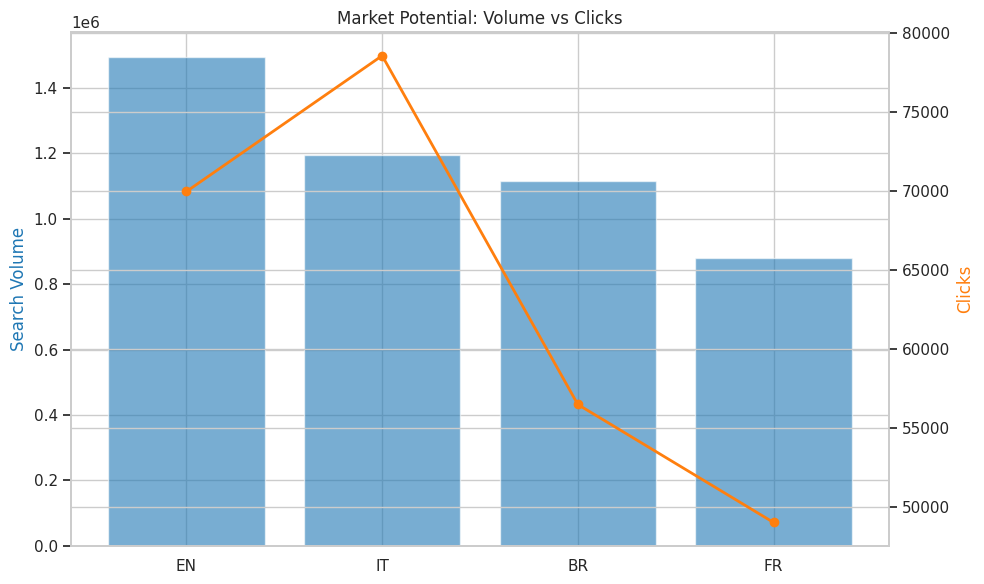

In [25]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(market_stats.index, market_stats['search_volume'], color='tab:blue', alpha=0.6, label='Volume')
ax1.set_ylabel('Search Volume', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(market_stats.index, market_stats['clicks'], color='tab:orange', marker='o', lw=2, label='Clicks')
ax2.set_ylabel('Clicks', color='tab:orange')
plt.title('Market Potential: Volume vs Clicks')
plt.tight_layout()
plt.savefig('market_potential.png')
plt.show()

/tmp/ipykernel_18242/3542204005.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_keywords.values, y=top_keywords.index, palette='viridis')


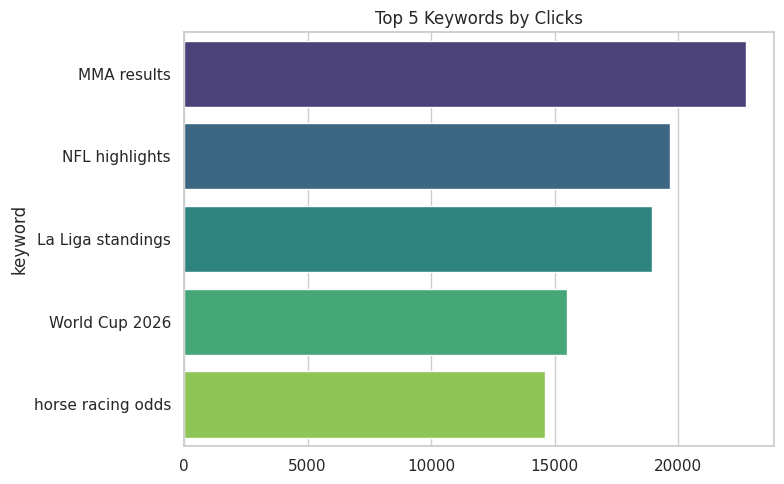

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(x=top_keywords.values, y=top_keywords.index, palette='viridis')
plt.title('Top 5 Keywords by Clicks')
plt.tight_layout()
plt.savefig('top_keywords.png')

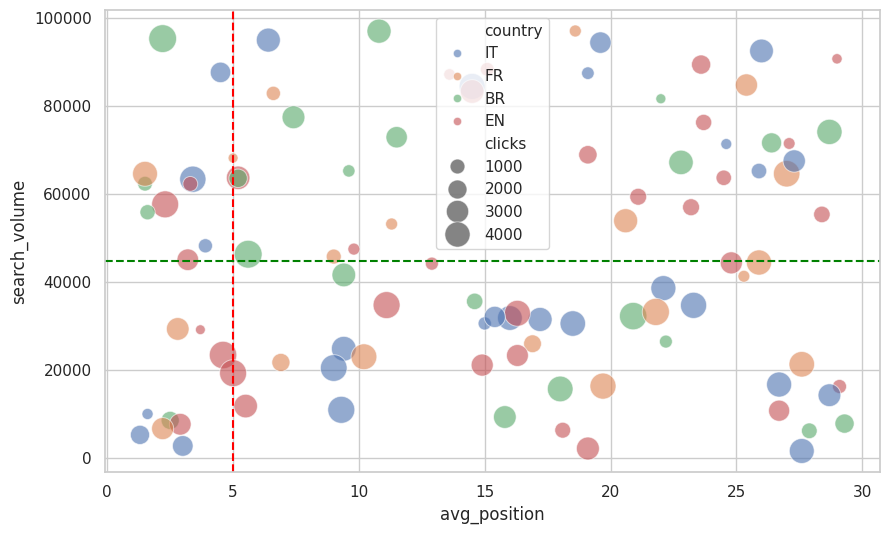

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='avg_position', y='search_volume', hue='country', size='clicks', sizes=(50, 400), alpha=0.6)
plt.axvline(x=5, color='red', ls='--')
plt.axhline(y=median_vol, color='green', ls='--')

In [21]:
gap_data = comp_gaps[['keyword', 'country', 'avg_position', 'competitor_position']].melt(
    id_vars=['keyword', 'country'], var_name='Type', value_name='Rank'
)
gap_data['Type'] = gap_data['Type'].replace({'avg_position': 'Competitor', 'competitor_position': 'You'})


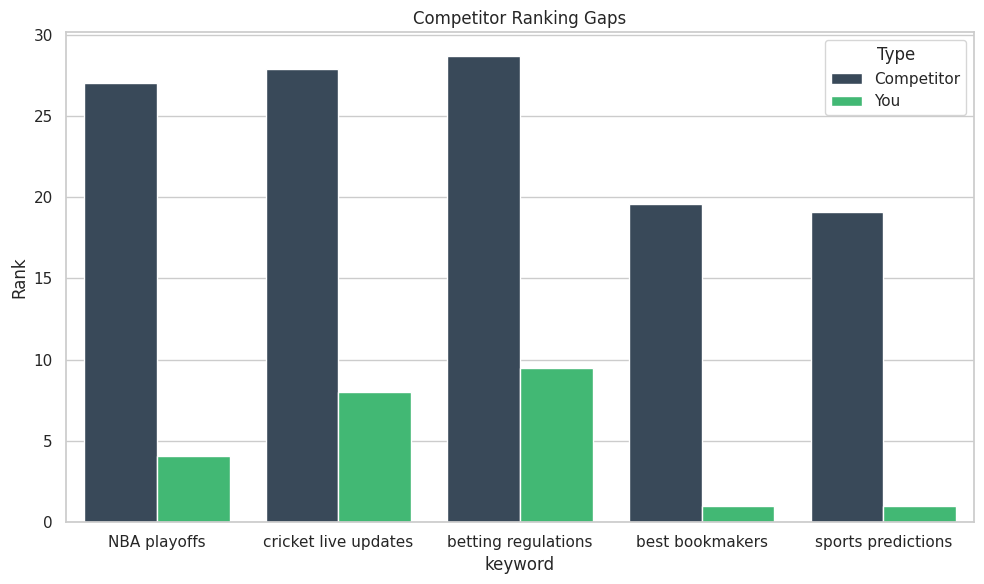

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(data=gap_data, x='keyword', y='Rank', hue='Type', palette=['#34495e', '#2ecc71'])
plt.title('Competitor Ranking Gaps')
plt.tight_layout()
plt.savefig('competitor_gaps.png')